# EXPERIMENTO 1 - Escala de imagens

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
def bilinear_resize(img_array, new_h, new_w):
  """Redimensiona imagem usando interpolação bilinear."""
  h, w = img_array.shape[:2]
  output = np.zeros((new_h, new_w, *img_array.shape[2:]),
  dtype=np.float64)
  # Fatores de escala
  scale_y = h / new_h
  scale_x = w / new_w
  for i in range(new_h):
    for j in range(new_w):
      # Posição contínua na imagem original
      y = i * scale_y
      x = j * scale_x
      # Coordenadas inteiras dos 4 vizinhos
      y0 = int(np.floor(y))
      x0 = int(np.floor(x))
      y1 = min(y0 + 1, h - 1)
      x1 = min(x0 + 1, w - 1)
      # Pesos fracionários (distância subpixel)
      dy = y - y0
      dx = x - x0
      # Interpolação bilinear
      output[i, j] = (
        (1-dx)*(1-dy) * img_array[y0, x0] +
        dx*(1-dy) * img_array[y0, x1] +
        (1-dx)*dy * img_array[y1, x0] +
        dx*dy * img_array[y1, x1]
      )
  return np.clip(output, 0, 255).astype(np.uint8)

/tmp/ipykernel_49212/668030093.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_pil = Image.fromarray(test, mode='L')


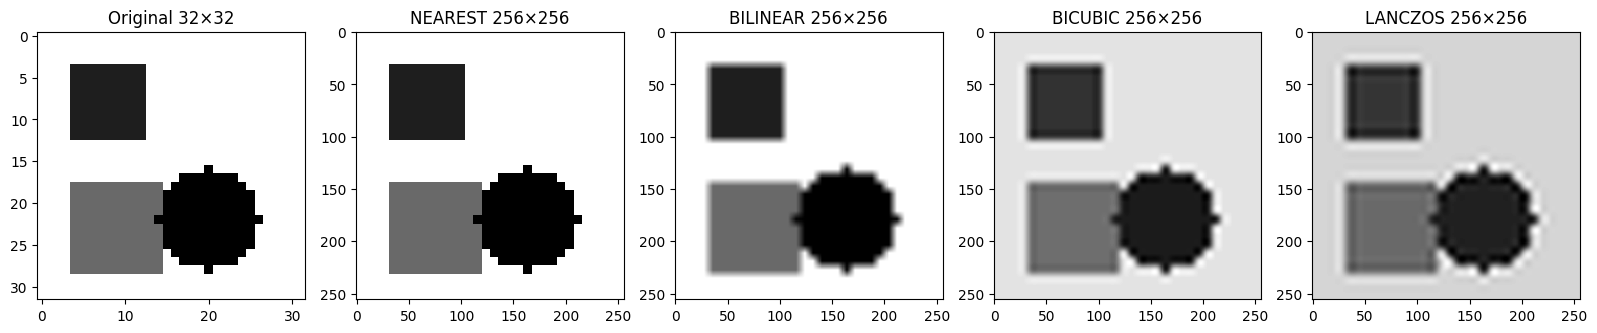

In [4]:
# Criar imagem de teste
test = np.zeros((32, 32), dtype=np.uint8)
test[4:13, 4:13] = 50 # Quadrado escuro
test[18:29, 4:15] = 100 # Retângulo
# Círculo usando distância euclidiana
Y, X = np.ogrid[:32, :32]
mask = (X-20)**2 + (Y-22)**2 <= 36
test[mask] = 30
test[~mask & (test == 0)] = 200 # Fundo claro
img_pil = Image.fromarray(test, mode='L')
methods = {
 'NEAREST': Image.NEAREST,
 'BILINEAR': Image.BILINEAR,
 'BICUBIC': Image.BICUBIC,
 'LANCZOS': Image.LANCZOS,
}
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
axes[0].imshow(test, cmap='gray', interpolation='nearest')
axes[0].set_title('Original 32×32')
for idx, (name, method) in enumerate(methods.items()):
  up = img_pil.resize((256, 256), method)
  axes[idx+1].imshow(np.array(up), cmap='gray',
  interpolation='nearest')
  axes[idx+1].set_title(f'{name} 256×256')
plt.tight_layout()
plt.savefig('comparacao_escala.png', dpi=150)
plt.show()

In [5]:
def psnr(original, processed):
  """Calcula Peak Signal-to-Noise Ratio em dB."""
  mse = np.mean((original.astype(float)
  - processed.astype(float))**2)
  if mse == 0:
    return float('inf')
  return 10 * np.log10(255**2 / mse)
# Exemplo: reduzir e ampliar de volta
for name, method in methods.items():
 small = img_pil.resize((8, 8), method)
 back = small.resize((32, 32), method)
 p = psnr(test, np.array(back))
 print(f'{name:10s} -> PSNR = {p:.2f} dB')

NEAREST    -> PSNR = 16.32 dB
BILINEAR   -> PSNR = 17.46 dB
BICUBIC    -> PSNR = 18.75 dB
LANCZOS    -> PSNR = 18.83 dB


# EXPERIMENTO 2 - Renderização de fontes

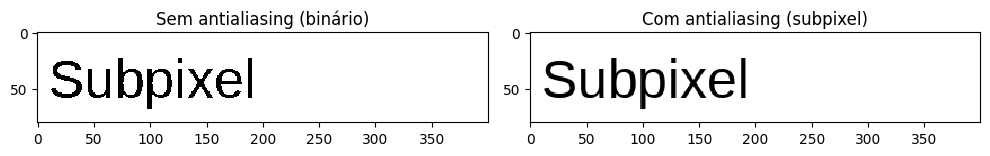

In [8]:
from PIL import Image, ImageDraw, ImageFont
def render_text_comparison(text, font_size=48):
  """Compara renderização binária vs antialiased."""
  font = ImageFont.truetype(
  '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf',
  font_size)
  # Com antialiasing (modo 'L' = grayscale)
  img_aa = Image.new('L', (400, 80), 255)
  draw_aa = ImageDraw.Draw(img_aa)
  draw_aa.text((10, 15), text, fill=0, font=font)
  # Sem antialiasing (binarizar com threshold)
  img_bin = img_aa.point(lambda x: 0 if x < 128 else 255)
  return img_bin, img_aa
img_bin, img_aa = render_text_comparison('Subpixel')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.imshow(np.array(img_bin), cmap='gray',
 interpolation='nearest')
ax1.set_title('Sem antialiasing (binário)')
ax2.imshow(np.array(img_aa), cmap='gray',
 interpolation='nearest')
ax2.set_title('Com antialiasing (subpixel)')
plt.tight_layout()
plt.show()

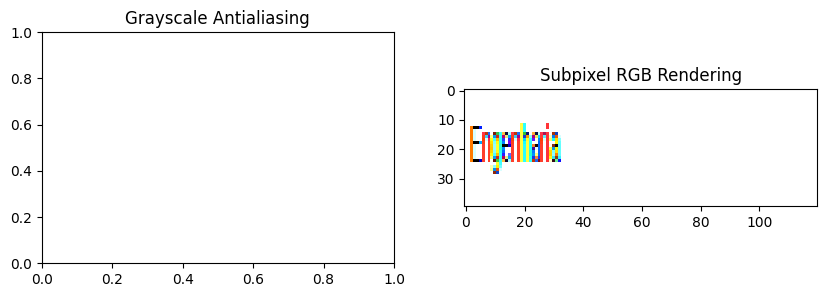

In [24]:
def subpixel_render(text, font_size=16, width=120,
 height=40):
 """Simula subpixel rendering RGB para LCD."""
 font = ImageFont.truetype(
 '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf',
 font_size)
 # Passo 1: Renderizar em 3x na horizontal
 img_3x = Image.new('L', (width * 3, height), 255)
 draw = ImageDraw.Draw(img_3x)
 draw.text((6, 8), text, fill=0, font=font)
 arr_3x = np.array(img_3x, dtype=np.float64) / 255.0
 # Passo 2: Mapear para canais RGB
 rgb = np.ones((height, width, 3))
 for x in range(width):
  rgb[:, x, 0] = arr_3x[:, x*3] # Red
  rgb[:, x, 1] = arr_3x[:, x*3 + 1] # Green
  rgb[:, x, 2] = arr_3x[:, x*3 + 2] # Blue
 return rgb
# Comparar grayscale AA vs subpixel RGB
text_sub = subpixel_render('Engenharia', 18)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.set_title('Grayscale Antialiasing')
ax2.imshow(text_sub, interpolation='nearest')
ax2.set_title('Subpixel RGB Rendering')
plt.show()

# EXPERIMENTO 3 - Análise avançada

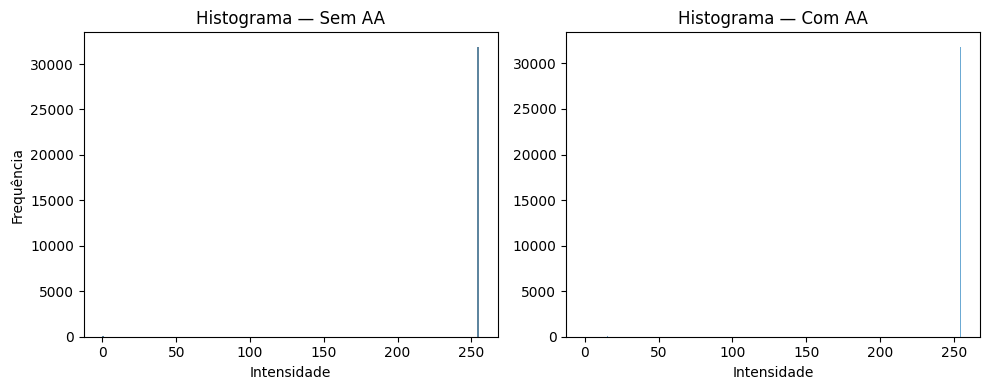

In [25]:
# Histograma comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(np.array(img_bin).ravel(), bins=256,
 range=(0,255), color='#1A5276', alpha=0.7)
ax1.set_title('Histograma — Sem AA')
ax1.set_xlabel('Intensidade')
ax1.set_ylabel('Frequência')
ax2.hist(np.array(img_aa).ravel(), bins=256,
 range=(0,255), color='#2E86C1', alpha=0.7)
ax2.set_title('Histograma — Com AA')
ax2.set_xlabel('Intensidade')
plt.tight_layout()
plt.savefig('histograma_aa.png', dpi=150)
plt.show()

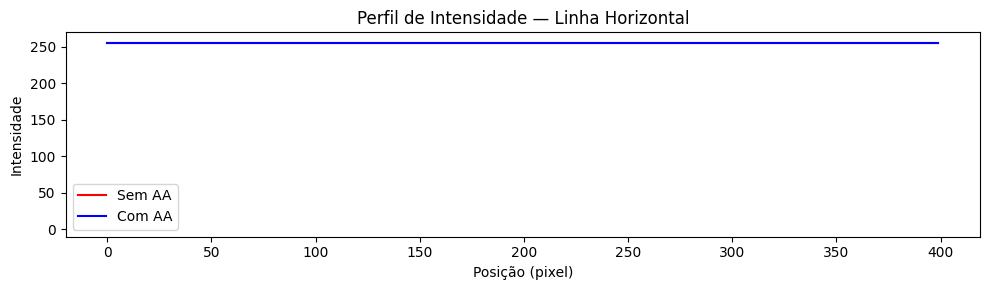

In [26]:
# Perfil de linha na altura do texto
row = 35 # Ajustar conforme a posição do texto
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.array(img_bin)[row, :], 'r-',
 label='Sem AA', linewidth=1.5)
ax.plot(np.array(img_aa)[row, :], 'b-',
 label='Com AA', linewidth=1.5)
ax.set_xlabel('Posição (pixel)')
ax.set_ylabel('Intensidade')
ax.set_title('Perfil de Intensidade — Linha Horizontal')
ax.legend()
ax.set_ylim(-10, 270)
plt.tight_layout()
plt.show()

# DESAFIOS EXTRAS

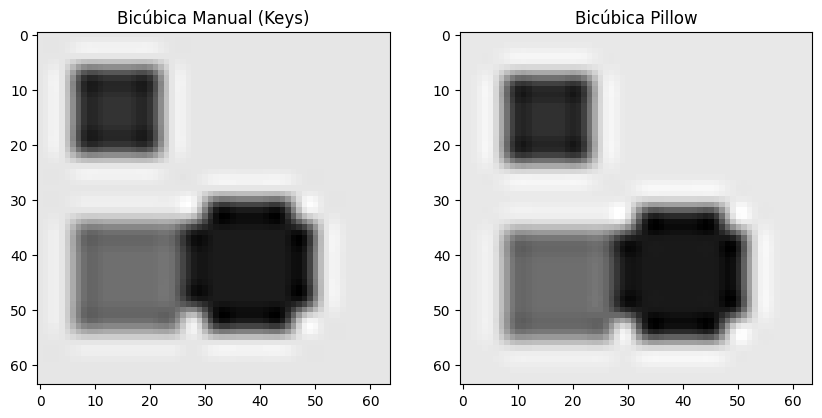

Diferença (MSE) entre Manual e Pillow: 601.4861


In [27]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def keys_kernel(x, a=-0.5):
    """Função Kernel de Keys para interpolação bicúbica."""
    x = abs(x)
    if x <= 1:
        return (a + 2) * (x**3) - (a + 3) * (x**2) + 1
    elif 1 < x < 2:
        return a * (x**3) - 5 * a * (x**2) + 8 * a * x - 4 * a
    return 0

def bicubic_manual(img, new_h, new_w):
    h, w = img.shape
    output = np.zeros((new_h, new_w))
    img_pad = np.pad(img, 2, mode='edge') # Padding para vizinhança 4x4

    sh, sw = h / new_h, w / new_w

    for i in range(new_h):
        for j in range(new_w):
            x, y = i * sh, j * sw
            xi, yi = int(x), int(y)
            dx, dy = x - xi, y - yi

            # Ajuste por causa do padding
            xi, yi = xi + 2, yi + 2

            # Somatório da vizinhança 4x4
            val = 0
            for m in range(-1, 3):
                for n in range(-1, 3):
                    weight = keys_kernel(m - dx) * keys_kernel(n - dy)
                    val += img_pad[xi + m, yi + n] * weight
            output[i, j] = val

    return np.clip(output, 0, 255).astype(np.uint8)

# Teste e Comparação
img_small = np.array(Image.fromarray(test).resize((16, 16), Image.NEAREST))
manual_res = bicubic_manual(img_small, 64, 64)
pillow_res = np.array(Image.fromarray(img_small).resize((64, 64), Image.BICUBIC))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(manual_res, cmap='gray'); ax1.set_title('Bicúbica Manual (Keys)')
ax2.imshow(pillow_res, cmap='gray'); ax2.set_title('Bicúbica Pillow')
plt.show()

mse_diff = np.mean((manual_res.astype(float) - pillow_res.astype(float))**2)
print(f"Diferença (MSE) entre Manual e Pillow: {mse_diff:.4f}")

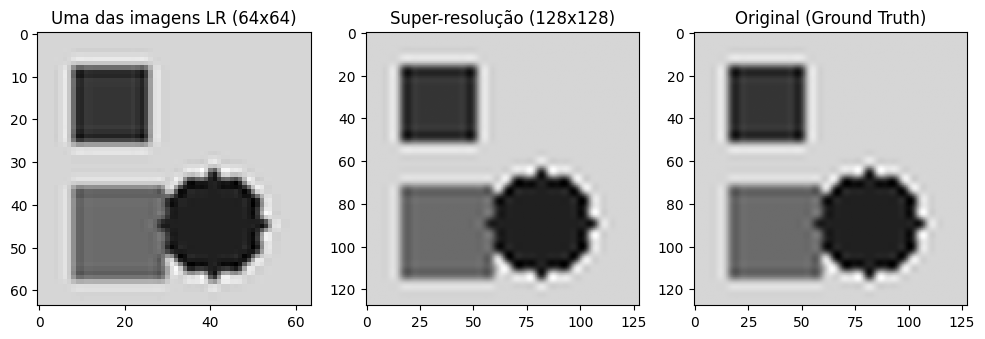

In [28]:
def generate_shifted_lowres(high_res_img):
    """Gera 4 imagens LR deslocadas por 0.5 pixel."""
    # Simula capturas com deslocamento subpixel
    # Imagem original deve ter tamanho par para este exemplo
    lr00 = high_res_img[0::2, 0::2] # (0, 0)
    lr01 = high_res_img[0::2, 1::2] # (0, 0.5) em escala original
    lr10 = high_res_img[1::2, 0::2] # (0.5, 0)
    lr11 = high_res_img[1::2, 1::2] # (0.5, 0.5)
    return lr00, lr01, lr10, lr11

def reconstruct_sr(lr00, lr01, lr10, lr11):
    """Combina as imagens LR para dobrar a resolução."""
    h, w = lr00.shape
    hr = np.zeros((h*2, w*2), dtype=np.uint8)
    hr[0::2, 0::2] = lr00
    hr[0::2, 1::2] = lr01
    hr[1::2, 0::2] = lr10
    hr[1::2, 1::2] = lr11
    return hr

# Exemplo com imagem do Lab
high_res = np.array(Image.fromarray(test).resize((128, 128), Image.LANCZOS))
lr_imgs = generate_shifted_lowres(high_res)
sr_img = reconstruct_sr(*lr_imgs)

plt.figure(figsize=(12, 4))
plt.subplot(131); plt.imshow(lr_imgs[0], cmap='gray'); plt.title('Uma das imagens LR (64x64)')
plt.subplot(132); plt.imshow(sr_img, cmap='gray'); plt.title('Super-resolução (128x128)')
plt.subplot(133); plt.imshow(high_res, cmap='gray'); plt.title('Original (Ground Truth)')
plt.show()

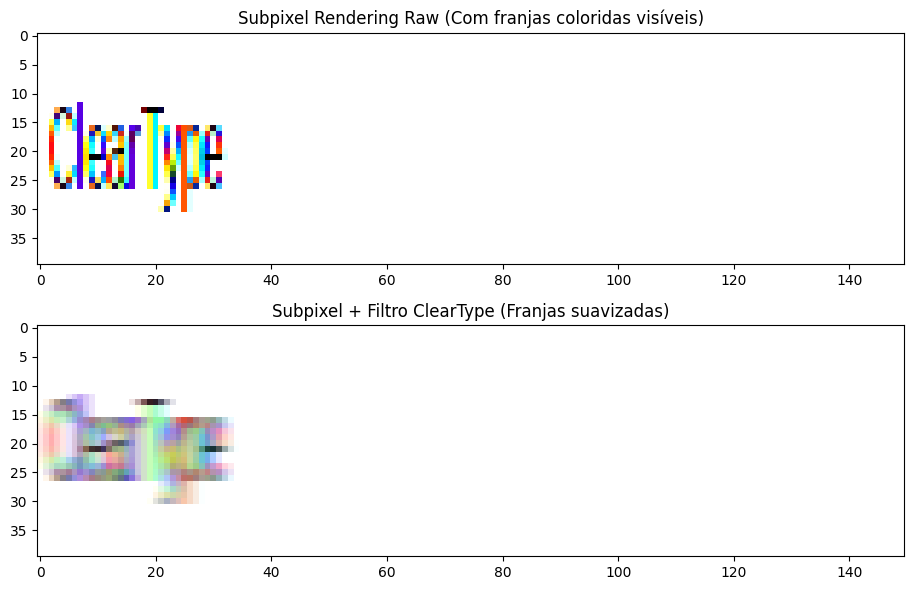

In [29]:
from scipy.ndimage import convolve1d

def apply_cleartype_filter(rgb_img):
    """
    Aplica um filtro FIR horizontal para reduzir franjas coloridas.
    O kernel [1/9, 2/9, 3/9, 2/9, 1/9] é um padrão comum.
    """
    # Kernel de suavização subpixel (horizontal apenas)
    kernel = np.array([1/9, 2/9, 3/9, 2/9, 1/9])

    # Aplicar convolução apenas no eixo X (colunas)
    filtered_rgb = np.zeros_like(rgb_img)
    for c in range(3):
        filtered_rgb[:,:,c] = convolve1d(rgb_img[:,:,c], kernel, axis=1)

    return filtered_rgb

# Gerar texto com subpixel do experimento anterior
text_raw = subpixel_render('ClearType', font_size=20, width=150)
text_filtered = apply_cleartype_filter(text_raw)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].imshow(text_raw, interpolation='nearest')
axes[0].set_title('Subpixel Rendering Raw (Com franjas coloridas visíveis)')
axes[1].imshow(text_filtered, interpolation='nearest')
axes[1].set_title('Subpixel + Filtro ClearType (Franjas suavizadas)')
plt.tight_layout()
plt.show()